In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)

# PARAMETERS
num_meters = 200
num_zones = 10
days = 14
hours_per_day = 24
total_hours = days * hours_per_day

# Create timestamps
timestamps = pd.date_range(start="2026-01-01", periods=total_hours, freq="H")

data = []

def base_pattern(hour):
    # Daily pattern: peaks morning + evening
    return 1.5 + np.sin((hour - 7) * np.pi / 12) + 0.5 * np.sin((hour - 19) * np.pi / 12)

for meter_id in range(num_meters):
    zone_id = meter_id % num_zones
    base_load = np.random.uniform(0.5, 2.0)

    # Assign scenario
    scenario = np.random.choice(
        ["normal", "vacation", "party", "fraud", "cross_meter", "appliance"],
        p=[0.5, 0.1, 0.1, 0.1, 0.1, 0.1]
    )

    for i, ts in enumerate(timestamps):
        hour = ts.hour

        # Base consumption
        consumption = base_load * base_pattern(hour)
        consumption += np.random.normal(0, 0.1)

        label = "normal"

        # ---- Scenario Injection ----
        if scenario == "vacation" and 3*24 < i < 8*24:
            consumption = 0.2 + np.random.normal(0, 0.02)
            label = "vacation"

        elif scenario == "party" and 5*24 < i < 5*24 + 6:
            consumption = base_load * 3 + np.random.normal(0, 0.2)
            label = "event"

        elif scenario == "fraud" and 6*24 < i < 10*24:
            consumption = 0.05 + np.random.normal(0, 0.01)
            label = "fraud"

        elif scenario == "appliance" and i > 7*24:
            consumption += 1.5
            label = "appliance"

        # Missing data simulation
        if np.random.rand() < 0.01:
            consumption = np.nan

        data.append([
            ts,
            meter_id,
            zone_id,
            max(consumption, 0),
            label
        ])

df = pd.DataFrame(data, columns=[
    "timestamp", "meter_id", "zone_id", "consumption", "label"
])

# Save
df.to_csv("synthetic_meter_data.csv", index=False)

print("Dataset generated:", df.shape)

/tmp/ipykernel_873/3656188125.py:14: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  timestamps = pd.date_range(start="2026-01-01", periods=total_hours, freq="H")


Dataset generated: (67200, 5)


In [ ]:
print(df['label'].value_counts())

label
normal       59271
appliance     3340
vacation      2499
fraud         1995
event           95
Name: count, dtype: int64


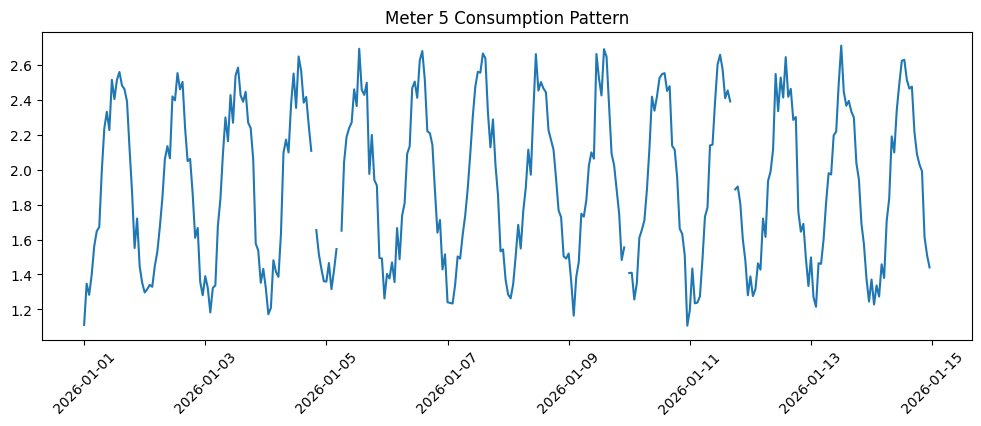

In [ ]:
import matplotlib.pyplot as plt

sample = df[df['meter_id'] == 5]
plt.figure(figsize=(12,4))
plt.plot(sample['timestamp'], sample['consumption'])
plt.title("Meter 5 Consumption Pattern")
plt.xticks(rotation=45)
plt.show()

In [ ]:
df.to_csv("synthetic_meter_data.csv", index=False)

In [ ]:
from google.colab import files
files.download("synthetic_meter_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("synthetic_meter_data.csv", parse_dates=["timestamp"])

# Sort properly
df = df.sort_values(by=["meter_id", "timestamp"])

# ---- 1. Handle Missing Values ----
df['consumption'] = df.groupby('meter_id')['consumption'].transform(
    lambda x: x.fillna(method='ffill').fillna(method='bfill')
)

# ---- 2. Time Features ----
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.dayofweek

# ---- 3. Rolling Features (per meter) ----
df['rolling_mean_24h'] = df.groupby('meter_id')['consumption'].transform(
    lambda x: x.rolling(window=24, min_periods=1).mean()
)

df['rolling_std_24h'] = df.groupby('meter_id')['consumption'].transform(
    lambda x: x.rolling(window=24, min_periods=1).std().fillna(0)
)

# ---- 4. Spike / Drop Detection ----
df['diff'] = df['consumption'] - df['rolling_mean_24h']

df['spike'] = df['diff'] > 1.5
df['drop'] = df['diff'] < -1.0

# ---- 5. Night Baseline (2 AM – 5 AM) ----
df['is_night'] = df['hour'].between(2, 5)

night_baseline = df[df['is_night']].groupby('meter_id')['consumption'].mean()

df['night_baseline'] = df['meter_id'].map(night_baseline)

# ---- Save processed data ----
df.to_csv("processed_meter_data.csv", index=False)

print("Preprocessing done:", df.shape)

/tmp/ipykernel_873/594890870.py:12: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lambda x: x.fillna(method='ffill').fillna(method='bfill')


Preprocessing done: (67200, 14)


In [ ]:
print(df.head())

            timestamp  meter_id  zone_id  consumption   label  hour  day  \
0 2026-01-01 00:00:00         0        0     1.144669  normal     0    3   
1 2026-01-01 01:00:00         0        0     1.214113  normal     1    3   
2 2026-01-01 02:00:00         0        0     1.237822  normal     2    3   
3 2026-01-01 03:00:00         0        0     1.209681  normal     3    3   
4 2026-01-01 04:00:00         0        0     1.170361  normal     4    3   

   rolling_mean_24h  rolling_std_24h      diff  spike   drop  is_night  \
0          1.144669         0.000000  0.000000  False  False     False   
1          1.179391         0.049104  0.034722  False  False     False   
2          1.198868         0.048411  0.038954  False  False      True   
3          1.201571         0.039896  0.008110  False  False      True   
4          1.195329         0.037263 -0.024968  False  False      True   

   night_baseline  
0        1.964241  
1        1.964241  
2        1.964241  
3        1.964241 

In [ ]:
# ---- Demand Prediction ----

import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# Load processed data
df = pd.read_csv("processed_meter_data.csv", parse_dates=["timestamp"])

# ---- 1. Aggregate zone-level demand ----
zone_df = df.groupby(['timestamp', 'zone_id'])['consumption'].sum().reset_index()

# Sort properly
zone_df = zone_df.sort_values(by=['zone_id', 'timestamp'])

# ---- 2. Create lag features ----
zone_df['lag_1'] = zone_df.groupby('zone_id')['consumption'].shift(1)
zone_df['lag_24'] = zone_df.groupby('zone_id')['consumption'].shift(24)

# ---- 3. Create baseline (moving average) ----
zone_df['baseline'] = zone_df.groupby('zone_id')['consumption'].transform(
    lambda x: x.rolling(24).mean()
)

# ---- 4. Drop rows with NaN (important fix) ----
zone_df = zone_df.dropna()

# ---- 5. Prepare data ----
features = ['lag_1', 'lag_24']
X = zone_df[features]
y = zone_df['consumption']

# ---- 6. Train model ----
model = LinearRegression()
model.fit(X, y)

# ---- 7. Predictions ----
zone_df['prediction'] = model.predict(X)

# ---- 8. Evaluation ----
mae_model = mean_absolute_error(y, zone_df['prediction'])
mae_baseline = mean_absolute_error(y, zone_df['baseline'])

print("Model MAE:", mae_model)
print("Baseline MAE:", mae_baseline)

# ---- 9. Load Score (FINAL FIX - NORMALIZED PER ZONE) ----

# Compute min and max per zone
zone_stats = zone_df.groupby('zone_id')['prediction'].agg(['min', 'max']).to_dict()

# Map min and max
zone_df['zone_min'] = zone_df['zone_id'].map(lambda z: zone_stats['min'][z])
zone_df['zone_max'] = zone_df['zone_id'].map(lambda z: zone_stats['max'][z])

# Normalize (0 to 1 scale)
zone_df['load_score'] = (
    (zone_df['prediction'] - zone_df['zone_min']) /
    (zone_df['zone_max'] - zone_df['zone_min'] + 1e-6)
)


# ---- 10. Risk classification ----
def classify_load(x):
    if x < 0.4:
        return "Safe"
    elif x < 0.7:
        return "Warning"
    else:
        return "High Risk"

zone_df['risk'] = zone_df['load_score'].apply(classify_load)

# ---- 11. Save ----
zone_df.to_csv("zone_predictions.csv", index=False)

# ---- 12. Preview ----
print(zone_df.head())

Model MAE: 1.5033119551407883
Baseline MAE: 7.067427449652965
              timestamp  zone_id  consumption      lag_1     lag_24  \
240 2026-01-02 00:00:00        0    26.375472  27.461518  26.497260   
250 2026-01-02 01:00:00        0    25.944519  26.375472  26.238217   
260 2026-01-02 02:00:00        0    26.413352  25.944519  26.124590   
270 2026-01-02 03:00:00        0    27.822082  26.413352  28.490196   
280 2026-01-02 04:00:00        0    29.628676  27.822082  30.045924   

      baseline  prediction   zone_min   zone_max  load_score  risk  
240  39.081739   27.226961  21.480401  53.927115    0.177108  Safe  
250  39.069502   26.425236  21.480401  53.927115    0.152399  Safe  
260  39.081533   26.103397  21.480401  53.927115    0.142480  Safe  
270  39.053695   27.220473  21.480401  53.927115    0.176908  Safe  
280  39.036310   28.677650  21.480401  53.927115    0.221817  Safe  


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest

# Load processed data
df = pd.read_csv("processed_meter_data.csv", parse_dates=["timestamp"])

# -------------------------------
# 1. Isolation Forest (ML anomaly)
# -------------------------------
features = ['consumption', 'rolling_mean_24h', 'rolling_std_24h', 'diff']

iso = IsolationForest(contamination=0.05, random_state=42)
df['anomaly_flag'] = iso.fit_predict(df[features])
df['anomaly_flag'] = df['anomaly_flag'].apply(lambda x: 1 if x == -1 else 0)


# -------------------------------
# 2. Zone + Neighbor Intelligence (IMPROVED)
# -------------------------------

# Zone average
zone_avg = df.groupby(['timestamp', 'zone_id'])['consumption'].mean().reset_index()
zone_avg.rename(columns={'consumption': 'zone_avg_consumption'}, inplace=True)
df = df.merge(zone_avg, on=['timestamp', 'zone_id'], how='left')

# Zone total (NEW - important)
zone_total = df.groupby(['timestamp','zone_id'])['consumption'].sum().reset_index()
zone_total.rename(columns={'consumption':'zone_total'}, inplace=True)
df = df.merge(zone_total, on=['timestamp','zone_id'])

# Neighbor deviation
df['neighbor_diff'] = df['consumption'] - df['zone_avg_consumption']

# Relative contribution (NEW - for cross-meter fraud)
df['relative_usage'] = df['consumption'] / df['zone_total']


# -------------------------------
# 3. Fraud Score (IMPROVED)
# -------------------------------
df['fraud_score'] = 0

# Sudden drop
df.loc[df['diff'] < -1.0, 'fraud_score'] += 2

# Near-zero consumption
df.loc[df['consumption'] < 0.1, 'fraud_score'] += 2

# No night baseline
df.loc[df['night_baseline'] < 0.2, 'fraud_score'] += 2

# ML anomaly
df.loc[df['anomaly_flag'] == 1, 'fraud_score'] += 1

# Neighbor mismatch
df.loc[df['neighbor_diff'] < -1.0, 'fraud_score'] += 1

# Cross-meter manipulation (NEW)
df.loc[
    (df['relative_usage'] < 0.01) &
    (df['zone_total'] > df['zone_total'].median()),
    'fraud_score'
] += 1


# -------------------------------
# 4. Event Score (IMPROVED)
# -------------------------------
df['event_score'] = 0

# Adaptive spike detection (better than fixed threshold)
df.loc[df['diff'] > df['rolling_std_24h'] * 2, 'event_score'] += 2

df.loc[df['rolling_std_24h'] > 0.8, 'event_score'] += 1


# -------------------------------
# 5. Vacation Detection
# -------------------------------
df['is_vacation'] = (
    (df['consumption'] < 0.5) &
    (df['rolling_std_24h'] < 0.2) &
    (df['night_baseline'] > 0.1)
)


# -------------------------------
# 6. Final Classification
# -------------------------------
def classify(row):
    if row['is_vacation']:
        return "Normal (Vacation)"
    if row['fraud_score'] >= 4:
        return "Fraud"
    if row['event_score'] >= 2:
        return "Event"
    if row['fraud_score'] >= 2:
        return "Suspicious"
    return "Normal"

df['prediction_label'] = df.apply(classify, axis=1)


# -------------------------------
# 7. Confidence Score (NEW 🔥)
# -------------------------------
df['confidence'] = (
    df['fraud_score'] * 0.6 +
    df['event_score'] * 0.4 +
    df['anomaly_flag'] * 0.5
)


# -------------------------------
# 8. Explainability (IMPROVED)
# -------------------------------
def generate_reason(row):
    reasons = []

    if row['is_vacation']:
        reasons.append("Low, stable usage → vacation pattern")

    if row['diff'] < -1.0:
        reasons.append(f"Usage dropped {abs(row['diff']):.2f}")

    if row['consumption'] < 0.1:
        reasons.append("Near-zero usage")

    if row['night_baseline'] < 0.2:
        reasons.append("No night baseline")

    if row['neighbor_diff'] < -1.0:
        reasons.append("Lower than nearby meters")

    if row['relative_usage'] < 0.01:
        reasons.append("Unusually low share in zone")

    if row['diff'] > row['rolling_std_24h'] * 2:
        reasons.append("Unusual spike")

    if row['rolling_std_24h'] > 0.8:
        reasons.append("High variability")

    if row['anomaly_flag'] == 1:
        reasons.append("ML anomaly detected")

    return " | ".join(reasons) if reasons else "Normal behavior"

df['explanation'] = df.apply(generate_reason, axis=1)


# -------------------------------
# 9. Save
# -------------------------------
df.to_csv("final_results.csv", index=False)

print("Final polished system ready ✅")

print(df[['meter_id','timestamp','prediction_label','fraud_score','event_score','confidence','explanation']].head())


# -------------------------------
# 10. Distribution
# -------------------------------
print("\nFinal Distribution:\n")
print(df['prediction_label'].value_counts())

Final polished system ready ✅
   meter_id           timestamp prediction_label  fraud_score  event_score  \
0         0 2026-01-01 00:00:00           Normal            0            0   
1         0 2026-01-01 01:00:00           Normal            0            0   
2         0 2026-01-01 02:00:00           Normal            0            0   
3         0 2026-01-01 03:00:00           Normal            0            0   
4         0 2026-01-01 04:00:00           Normal            0            0   

   confidence      explanation  
0         0.0  Normal behavior  
1         0.0  Normal behavior  
2         0.0  Normal behavior  
3         0.0  Normal behavior  
4         0.0  Normal behavior  

Final Distribution:

prediction_label
Normal               61938
Normal (Vacation)     3610
Suspicious             607
Fraud                  544
Event                  501
Name: count, dtype: int64


In [ ]:
print(df['prediction_label'].value_counts())

prediction_label
Normal               61938
Normal (Vacation)     3610
Suspicious             607
Fraud                  544
Event                  501
Name: count, dtype: int64


In [ ]:
df[df['prediction_label'] == 'Fraud'].head(10)

,timestamp,meter_id,zone_id,consumption,label,hour,day,rolling_mean_24h,rolling_std_24h,diff,...,zone_avg_consumption,zone_total,neighbor_diff,relative_usage,fraud_score,event_score,is_vacation,prediction_label,confidence,explanation
817,2026-01-07 01:00:00,2,2,0.055794,fraud,1,2,2.065599,0.674991,-2.009804,...,0.996845,19.936893,-0.941050,0.002799,5,0,False,Fraud,3.5,Usage dropped 2.01 | Near-zero usage | Unusual...
818,2026-01-07 02:00:00,2,2,0.047787,fraud,2,2,2.005844,0.783645,-1.958056,...,0.976978,19.539568,-0.929191,0.002446,5,0,False,Fraud,3.5,Usage dropped 1.96 | Near-zero usage | Unusual...
819,2026-01-07 03:00:00,2,2,0.036594,fraud,3,2,1.947424,0.874733,-1.910830,...,1.079748,21.594961,-1.043154,0.001695,6,1,False,Fraud,4.5,Usage dropped 1.91 | Near-zero usage | Lower t...
820,2026-01-07 04:00:00,2,2,0.048329,fraud,4,2,1.883517,0.954934,-1.835189,...,1.142155,22.843101,-1.093826,0.002116,6,1,False,Fraud,4.5,Usage dropped 1.84 | Near-zero usage | Lower t...
821,2026-01-07 05:00:00,2,2,0.062137,fraud,5,2,1.811803,1.024857,-1.749665,...,1.246995,24.939907,-1.184858,0.002491,6,1,False,Fraud,4.5,Usage dropped 1.75 | Near-zero usage | Lower t...
822,2026-01-07 06:00:00,2,2,0.056629,fraud,6,2,1.739147,1.085707,-1.682518,...,1.375659,27.513172,-1.319030,0.002058,6,1,False,Fraud,4.5,Usage dropped 1.68 | Near-zero usage | Lower t...
823,2026-01-07 07:00:00,2,2,0.053263,fraud,7,2,1.657174,1.136607,-1.603911,...,1.468982,29.379647,-1.415720,0.001813,6,1,False,Fraud,4.5,Usage dropped 1.60 | Near-zero usage | Lower t...
824,2026-01-07 08:00:00,2,2,0.053997,fraud,8,2,1.567932,1.175882,-1.513935,...,1.609820,32.196396,-1.555823,0.001677,6,1,False,Fraud,4.5,Usage dropped 1.51 | Near-zero usage | Lower t...
825,2026-01-07 09:00:00,2,2,0.050305,fraud,9,2,1.464844,1.196650,-1.414539,...,1.682832,33.656641,-1.632527,0.001495,6,1,False,Fraud,4.5,Usage dropped 1.41 | Near-zero usage | Lower t...
826,2026-01-07 10:00:00,2,2,0.053088,fraud,10,2,1.353076,1.198078,-1.299987,...,1.844686,36.893722,-1.791598,0.001439,7,1,False,Fraud,5.1,Usage dropped 1.30 | Near-zero usage | Lower t...


In [ ]:
from google.colab import files

files.download("zone_predictions.csv")
files.download("final_results.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
files.download("zone_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>